# **Setup**

- https://towardsdatascience.com/how-i-automated-my-machine-learning-workflow-with-just-10-lines-of-python/

In [1]:
# !pip install pycaret --quiet
# !pip install lazypredict --quiet 

In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from lazypredict.Supervised import LazyClassifier

In [3]:
# Load dataset
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"
df = pd.read_csv(url, header=None)

X = df.iloc[:, :-1]
y = df.iloc[:, -1]

# **LazyPredict**

In [4]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# LazyClassifier
clf = LazyClassifier(verbose=0, ignore_warnings=True)
models, predictions = clf.fit(X_train, X_test, y_train, y_test)

# Top 5 models
print(models.head(5))

  0%|          | 0/29 [00:00<?, ?it/s]

[LightGBM] [Info] Number of positive: 213, number of negative: 401
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000465 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 668
[LightGBM] [Info] Number of data points in the train set: 614, number of used features: 8
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.346906 -> initscore=-0.632669
[LightGBM] [Info] Start training from score -0.632669
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


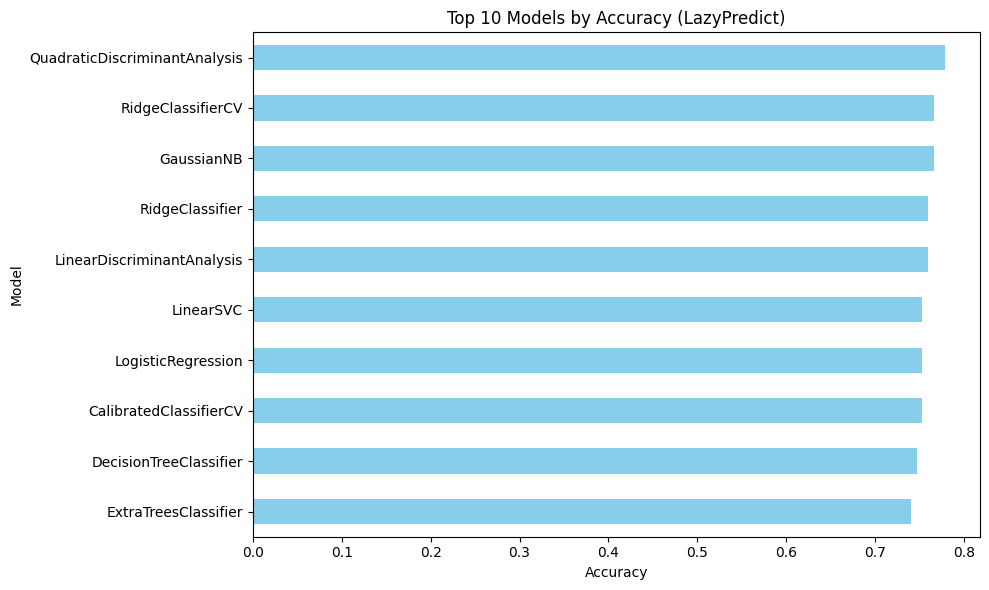

In [5]:
import matplotlib.pyplot as plt

# Assuming `models` is the LazyPredict DataFrame
top_models = models.sort_values("Accuracy", ascending=False).head(10)

plt.figure(figsize=(10, 6))
top_models["Accuracy"].plot(kind="barh", color="skyblue")
plt.xlabel("Accuracy")
plt.title("Top 10 Models by Accuracy (LazyPredict)")
plt.gca().invert_yaxis()
plt.tight_layout()

# **PyCaret**

In [6]:
from pycaret.classification import *  

clf = setup(data=df, target=df.columns[-1])
best_model = compare_models()

,Description,Value
0,Session id,3496
1,Target,8
2,Target type,Binary
3,Original data shape,"(768, 9)"
4,Transformed data shape,"(768, 9)"
5,Transformed train set shape,"(537, 9)"
6,Transformed test set shape,"(231, 9)"
7,Numeric features,8
8,Preprocess,True
9,Imputation type,simple


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
ridge,Ridge Classifier,0.7841,0.8366,0.5892,0.7475,0.6555,0.5018,0.5119,0.0060
lr,Logistic Regression,0.7824,0.8353,0.5898,0.7383,0.6521,0.4975,0.5065,0.3620
lda,Linear Discriminant Analysis,0.7823,0.8371,0.5892,0.7425,0.6534,0.4981,0.5078,0.0060
et,Extra Trees Classifier,0.7747,0.8364,0.5778,0.7240,0.6390,0.4791,0.4878,0.0310
rf,Random Forest Classifier,0.7727,0.8283,0.5985,0.7109,0.6447,0.4802,0.4879,0.0340
nb,Naive Bayes,0.7711,0.8219,0.6427,0.6808,0.6587,0.4875,0.4898,0.0060
xgboost,Extreme Gradient Boosting,0.7578,0.8037,0.6307,0.6623,0.6436,0.4609,0.4633,0.0170
gbc,Gradient Boosting Classifier,0.7577,0.8189,0.5991,0.6734,0.6298,0.4518,0.4566,0.0260
lightgbm,Light Gradient Boosting Machine,0.7558,0.8090,0.6038,0.6659,0.6298,0.4492,0.4531,0.1030
ada,Ada Boost Classifier,0.7541,0.7767,0.5506,0.6936,0.6110,0.4343,0.4429,0.0180
